In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:22px;}

</style>
"""))

**<font size="6" color="red">ch1허깅페이스 모델 사용</font>**
- Inference API 이용 : 모델의 결과를 server에서 
- pipline() 이용 : 모델을 다운받아 모델의 결과를 local에서 

- 허깅페이스 transformer에서 지원하는 task

|task값| 설명 |
|:--- | :--- |
|text-classification (별칭 sentiment-analysis)|	감정 분석, 뉴스 분류, 리뷰 분류 등 문장 분류|
|zero-shot-classification	|레이블에 대한 별도 학습 없이 후보 레이블 중에서 분류|
|text-generation	        |GPT 계열 모델을 이용한 텍스트 생성|
|fill-mask	                |문장 안의 빈칸(마스크)에 들어갈 단어 예측|
|ner (token-classification의 별칭)|	개체명 인식(사람, 조직, 장소 등 라벨링)|
|question-answering	|주어진 지문(context)을 근거로 질문에 답변|
|summarization	            |긴 문서를 짧게 요약|
|translation	            |서로 다른 언어 간 번역|
|image-to-text	            |이미지 내용을 설명하는 문장 생성|
|image-classification	    |이미지가 어떤 대상인지 분류|

 
- 처음 모델 사용시 "c:/Users/내컴퓨터이름/.cache/huggingface"에 다운로드 되느라 시간이 걸림    

In [1]:
import warnings
import os
import logging
 
# 경고 메시지 제거
warnings.filterwarnings('ignore')
 
# transformers 라이브러리의 로깅 레벨을 ERROR로 조정 (경고 숨김)
logging.getLogger("transformers").setLevel(logging.ERROR)
 
#Hugging Face 캐시 관련 symlink 경고 제거
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


## 1.텍스트 기반 감정분석(긍정/부정)
- 토큰화 -> 워드임배딩 -> 모델 -> predict : pipline()함수는 이 단계를 내부적으로 해 줌

In [5]:
from transformers import pipeline
classifier = pipeline(task="text-classification",
                     model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
    
classifier("I`ve been waiting for a Hugging face course my whole life.")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9978979825973511}]

In [8]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel
model=AutoModel.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")
# 전체 파라미터 수 
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 66,362,880
전체 파라미터 수: 63.289MB


In [9]:
from transformers import pipeline
classifier = pipeline(task = "text-classification",
                     model = "distilbert/distilbert-base-uncased-finetuned-sst-2-english")
# 감정분석할 내용이 많으면 list
classifier([
    "I`ve been waiting for a Hugging face course my whole life.",            
    "I hate this so much!"
])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9978979825973511},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [10]:
classifier("이 영화 재미있어요.")

[{'label': 'POSITIVE', 'score': 0.8855457305908203}]

In [11]:
classifier(["I love you","I hate you","힘들어요"])

[{'label': 'POSITIVE', 'score': 0.9998656511306763},
 {'label': 'NEGATIVE', 'score': 0.9991129040718079},
 {'label': 'POSITIVE', 'score': 0.8669537305831909}]

In [13]:
classifier = pipeline(task= "sentiment-analysis",
                     model = "daekeun-ml/koelectra-small-v3-nsmc")
texts = ['힘들어요','오늘기분최고야','당신이 싫어요','니가 참좋아']
classifier(texts)

Device set to use cpu


[{'label': '0', 'score': 0.9957089424133301},
 {'label': '1', 'score': 0.9991125464439392},
 {'label': '0', 'score': 0.793237030506134},
 {'label': '1', 'score': 0.9421136379241943}]

In [14]:
for text, result in zip(texts, classifier(texts)):
    label = "긍정" if result['label']=='1' else "부정"
    print(f"'{text}'->{label}{result['score']:.2%}")

'힘들어요'->부정99.57%
'오늘기분최고야'->긍정99.91%
'당신이 싫어요'->부정79.32%
'니가 참좋아'->긍정94.21%


## 2. 제로샷(zero-shot)

In [6]:
from transformers import pipeline
classifier = pipeline(task='zero-shot-classification',
                     model = 'facebook/bart-large-mnli')
classifier("I have a problem with my iphone that needs to be resolved asap!!",
          candidate_labels=["urgent", "not urgent", "phone", "tablet", "computer"])

Device set to use cpu


{'sequence': 'I have a problem with my iphone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'not urgent', 'tablet'],
 'scores': [0.5036354660987854,
  0.47879987955093384,
  0.012600138783454895,
  0.002655791351571679,
  0.0023087516892701387]}

In [9]:
classifier("This is a course about the Transformers library",
            candidate_labels=["education", "business","phone"])

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'phone'],
 'scores': [0.7937667965888977, 0.10523490607738495, 0.10099823772907257]}

## 3. text 생성
- gpt2 : 파라미터 겟수가 0.1B(124,439,808개)
- 모델용량 : 124,439,808*4 =>118.675MB
- finetuning시 추가메모리 : 학습시 활성화함수, 옵티마이저, 미분, 데이터 등으로 4배 정도 메모리 필요

In [10]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel
model=AutoModel.from_pretrained("gpt2")
# 전체 파라미터 수 
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 124,439,808
전체 파라미터 수: 118.675MB


In [15]:
generator = pipeline(task = "text-generation",
                    model="gpt2")
generator("In this course. We will teach you to",
         pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': "In this course. We will teach you to use the right tools to perform your project quickly and accurately. We will also show you the tools you need to know when working with an interactive web application.\n\nWhat is the Python scripting language?\n\nPython is an open-source programming language with the Python programming language being used by many major web developers. The Python scripting language is a set of tools for many websites, including:\n\nPython client for Windows\n\nPython client for Macintosh\n\nPython client for Linux\n\nPython client for Mac OS X\n\nPython client for Linux\n\npython2d for Mac OS X\n\nPython2d for Windows\n\nPython2d for Mac OS X\n\nPython2d for Linux\n\nPython2d for Windows\n\nPython2d for Mac OS X\n\nPython2d for Mac OS X\n\nWe will demonstrate how to use Python 2D for web development. We will work with Java for development and Python for production.\n\nWhat is Visual Studio?\n\nVisual Studio is a highly customizable, cross-platform

In [17]:
result = generator("In this course. We will teach you to",
         pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course. We will teach you to create and use image recognition in all your online applications. This course is a good starting point for you to get started with image recognition and you will be able to develop better tools for image recognition, including Google Cardboard, Google Cardboard with Image Recognition, Google Cardboard with Image Recognition and Google Cardboard with Image Recognition.

To get started with image recognition you will need to understand how your application will look in real-time. When you create an image you will have to determine the current position in the image. You will need to create two different layers of the image. The first layer of the image is the image layer 3, which is where you draw the image into the computer. This layer 3 will be connected to the other two layers of the image layer 1 which are connected to the computer. The image layer 3 will look like this:

The second layer of the image layer 1 is the image layer 4. This layer 4 is c

In [18]:
result = generator("In this course. We will teach you how to ",
         pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course. We will teach you how to  use the "nesting box" to create a nested container.
We will create a new container, and get the user to login using the username.
We will use the "login" method to get the user to login, while the "password" method will get the user to login using his password.
Once you create a container, you will have to create a "nesting box" for the user.
Now, the first time you log in as the user, you will have to create the nested container.
To do so, you will need to create a new "nesting box" for the user.
You will also need to create a new "password" method for the user. Once you create that, you will have to use the "login" method to get the user to login using the username.
Finally, we will use the "nesting box" to create the user.
Finally, we will create a new container, and get the user to login using the username.
We can now call this function in the nested container to get the user to login:
$container = New-Object System.Web.Http.HttpClient $con

In [23]:
from transformers import pipeline, set_seed
# set_seed(2)
generator = pipeline("text-generation","skt/kogpt2-base-v2",
                    device=-1)
prompt = "이 과정은 다음과 같은것을 알려드려요"
result = generator(prompt,
                  pad_token_id=generator.tokenizer.eos_token_id,
                  max_new_tokens=20,
                  do_sample=True,  #샘플링 사용
                  top_k = 50,      # 토큰후보 폭을 다양하게 확보
                  temperature=0.8, # 0.2는 너무 보수적, 0.9정도는유연한 대답 
                  top_p=0.9,       # 상위 90% 누적 확률 토큰만
                  repetition_penalty=1.2 # 반복적인 패널티를  
                  ) 
print(result[0]['generated_text'])

Device set to use cpu


이 과정은 다음과 같은것을 알려드려요!
그냥 이걸로 끝이에요.
사실 이건 조금 이상한거예요.
이건 그냥 그 자체가 신기


## 4. 마스크 채우기

In [26]:
unmasker = pipeline(task="fill-mask",
                 model="distilbert/distilroberta-base")
unmasker("I`m going to hospital and meet a <mask>",top_k=2)

Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.23512926697731018,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': 'I`m going to hospital and meet a doctor'},
 {'score': 0.08574394136667252,
  'token': 16308,
  'token_str': ' surgeon',
  'sequence': 'I`m going to hospital and meet a surgeon'}]

In [ ]:
# unmasker = pipeline("fill-mask", "v")
# unmasker("Hello, I'm a [MASK] model.")

In [27]:
unmasker("병원에가서<mask>를 만날거에요",top_k=2)

[{'score': 0.3197586238384247,
  'token': 1437,
  'token_str': ' ',
  'sequence': '병원에가서 를 만날거에요'},
 {'score': 0.10290026664733887,
  'token': 12,
  'token_str': '-',
  'sequence': '병원에가서-를 만날거에요'}]

### inference API이용
-  모델의 결과를 server에게 

In [31]:
import os
from dotenv import load_dotenv
load_dotenv()
print(os.getenv("HF_TOKEN")[:2])

hf


In [34]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    provider='hf-inference',
    api_key=os.getenv('HF-TOKEN')
)
result = client.fill_mask("Hello, I'm a [MASK] model.",
                         model="google-bert/bert-base-uncased",
                         #top_k=2
                         )
result

[FillMaskOutputElement(score=0.1441427320241928, sequence="hello, i ' m a role model.", token=2535, token_str='role', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.14175812900066376, sequence="hello, i ' m a fashion model.", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.06221463158726692, sequence="hello, i ' m a new model.", token=2047, token_str='new', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04102848470211029, sequence="hello, i ' m a super model.", token=3565, token_str='super', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.02591117098927498, sequence="hello, i ' m a business model.", token=2449, token_str='business', fill_mask_output_token_str=None)]

In [35]:
[r.sequence for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

In [40]:
# 다국어 지원되는 mask모델
unmasker = pipeline("fill-mask","google-bert/bert-base-multilingual-cased")
unmasker("안녕하세요. 나는 [MASK]모델입니다",top_k=3)

Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.19656884670257568,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕하세요. 나는 가수 모델입니다'},
 {'score': 0.13671785593032837,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕하세요. 나는 여자 모델입니다'},
 {'score': 0.048979904502630234,
  'token': 102574,
  'token_str': '프로',
  'sequence': '안녕하세요. 나는 프로 모델입니다'}]

## 5. 개체명 인식(NER;Named Entity Recognition)

In [44]:
new = pipeline("ner",
               "dbmdz/bert-large-cased-finetuned-conll03-english",
               grouped_entities=True) # 객체들을 그룹으로 묶을지 말지
new("My name is Sylvain and I work at Hygging Face in Brooklyn.")

[{'entity_group': 'PER',
  'score': np.float32(0.99811614),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9334414),
  'word': 'Hygging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9935315),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

## 6. 질의응답
- context에 대한 질의 응답

In [46]:
question_answer = pipeline("question-answering")
question_answer(
    question="Where do I work? ",
    context= "My name is Sylvain and I work at Hugging Face in Brooklyn."
)# context 지문을 이용해서 답하는것

{'score': 0.68299800157547, 'start': 33, 'end': 45, 'answer': 'Hygging Face'}

In [47]:
context= "My name is Sylvain and I work at Hugging Face in Brooklyn."
context[33:45]

'Hygging Face'

## 7. 문서요약
- torch 버전 2.6보다 낮으면 문서요약이 안될수도있음

In [49]:
summarizer = pipeline("summarization",
                     "facebook/bart-large-cnn")
summarizer('''
Although Son Heung-min missed the chance to score after hitting a decisive shot on the post, 
his club LAFC crushed the New York Red Bulls and tasted the joy of victory for the first time in seven games.
On the 10th, LAFC defeated the New York Red Bulls 2-0 in a 25th round MLS regular-season home game held at BMO Stadium in Los Angeles, California. 
LAFC, which had stumbled in the last six matches with 4 draws and 2 losses, finally added 3 points and reached 40 points, climbing up to third place in the Western Conference.
Son Heung-min, who scored his first goal in eight matches with one goal and one assist in the previous game, 
started as the lone striker and played the full match. 
They threatened New York’s goal several times, but luck was not on their side,
as their decisive shot in the second half struck the crossbar and they failed to score for the second consecutive match.
Son Heung-min, who had been actively looking for shooting opportunities from the start,
picked up a ball coming from the left in the 12th minute of the first half and attempted a left-footed shot from the center of the penalty area, but was stopped by a defender who dived in.
New York immediately counterattacked as well. At the 15th minute of the first half, 
Eric Choupo-Moting cut into the right side of the penalty area and fired a powerful right-footed shot, 
but LAFC goalkeeper Hugo Lloris dived to block it.
''',
          max_length=130,
          min_length=30,
          do_sample=True)

[{'summary_text': 'LAFC beat New York Red Bulls 2-0 in the 25th round of the MLS season. Son Heung-min scored the only goal of the game. LAFC moved up to third place in the Western Conference, one point behind New York.'}]

## 8. 번역

In [50]:
# pip install sacremoses
translator = pipeline('translation',
                     'Helsinki-NLP/opus-mt-fr-en') # 불어를 영어로 번역

In [51]:
translator('Ce cours est produit par Huhhing Face')

[{'translation_text': 'This course is produced by Huhhing Face'}]

In [55]:
# 한->영
ko2en=pipeline("translation",model='Helsinki-NLP/opus-mt-ko-en')
# 영->한(불량)
en2ko = pipeline("translation",model="Helsinki-NLP/opus-mt-tc-big-en-ko")
# 테스트문장
ko_sentence = "이 문장을 영어로 번역해주세요"
en_sentence = "I enjoy learning about AI"
# 번역
print('한>영:',ko2en(ko_sentence)[0]['translation_text'])
print('영>한:',en2ko(en_sentence)[0]['translation_text'])

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: e763de47-4d2e-41d9-9446-882b579bced9)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-ko-en/e42d1f41b66194e6d10512f8a27bebc1f4f5097e/config.json
Retrying in 1s [Retry 1/5].


한>영: Please translate this sentence into English.
영>한: US  풍선 행


In [58]:
result=ko2en([
    '안녕하세요 즐거운 하루 보내세요',
    '내일부터는 open ai API를 공부합니다.',
    '결제를 위해 직불카드 지참 바랍니다.'
])
[r['translation_text'] for r in result]

['Hello. Have a nice day.',
 "So tomorrow we're going to study the open ai APl.",
 "I'd like you to check your credit card for the payment."]

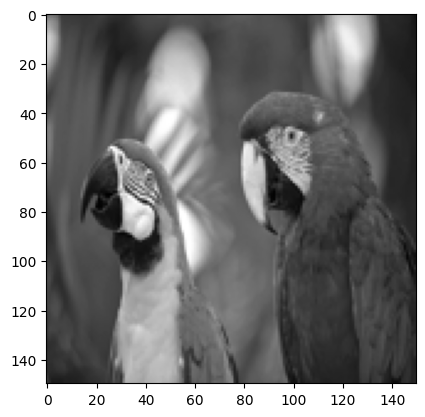

In [4]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests
import numpy as np
response = requests.get(url,stream=True).raw
image = Image.open(response)
image = image.resize((150,150))
image_npy = np.array(image)

import matplotlib.pyplot as plt
plt.imshow(image_npy,cmap='gray')

In [5]:
from transformers import pipeline
imagetotext = pipeline("image-to-text",
                      "ydshieh/vit-gpt2-coco-en")
imagetotext(url, max_new_tokens=30) # 30토큰 내로 설명

Device set to use cpu
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


[{'generated_text': 'two birds are standing next to each other '}]

In [6]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(url, stream=True).raw
image = Image.open(response)
imagetotext(url, max_new_tokens=50)

[{'generated_text': 'a cat laying on a blanket next to a cat laying on a bed '}]

In [7]:
filename = 'images/fb.jpg'
#Image.open(filename)
imagetotext(filename, max_new_tokens=50)

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

## 10. 이미지분류

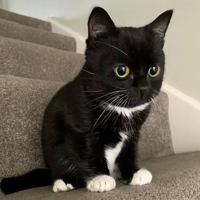

In [8]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

In [9]:
imgclassifier = pipeline("image-classification",
                        "google/vit-base-patch16-224")
imgclassifier(image)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 49fadb8c-7f2b-440b-850c-8b70328cc4a4)')' thrown while requesting HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: a300e33d-56bd-43e5-ab8b-f97dcf8bc86d)')' thrown while requesting HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 94fa908a-1483-4a90-8d0f-95bbbf89ae05)')' thrown while requesting HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout

[{'label': 'Egyptian cat', 'score': 0.853131890296936},
 {'label': 'tabby, tabby cat', 'score': 0.04750382527709007},
 {'label': 'tiger cat', 'score': 0.03486618399620056},
 {'label': 'Persian cat', 'score': 0.007555846590548754},
 {'label': 'Siamese cat, Siamese', 'score': 0.003788588335737586}]